# 01. SCATS Traffic Volumes EDA (sudheer)
**Team B - Traffic Volumes & Parking | Sprint 1**

Prototypes the traffic-volumes half of the sprint story: *"...aggregates event streams into
hourly average ... traffic volumes so that data is summarized for performant serving."*

Source: SCATS Traffic Signal Volume Data (15-minute interval counts per detector per site,
statewide, downloaded in `00_data_ingestion.ipynb`), filtered to the **1,325 inner-Melbourne
sites** identified in that notebook. Data covers **1-14 August 2026** (the days published so far
for the current month).

Each raw row is one detector at one SCATS site on one day, with 96 columns `V00`-`V95` holding the
15-minute interval vehicle counts for that 24-hour period.


In [1]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAW_DIR = Path("../../../data/raw")
PROCESSED_DIR = Path("../../../data/processed")
plt.rcParams["figure.figsize"] = (10, 4)


## 1. Load + filter to inner-Melbourne sites

In [2]:
sites = pd.read_csv(PROCESSED_DIR / "scats_inner_melbourne_sites.csv")
site_ids = set(sites["SITE_NO"])
print(f"{len(site_ids)} inner-Melbourne SCATS sites to filter against.")

daily_files = sorted(glob.glob(str(RAW_DIR / "scats_extracted" / "*.csv")))
print(f"{len(daily_files)} daily files available: {[Path(f).stem for f in daily_files]}")


1325 inner-Melbourne SCATS sites to filter against.
14 daily files available: ['VSDATA_20260801', 'VSDATA_20260802', 'VSDATA_20260803', 'VSDATA_20260804', 'VSDATA_20260805', 'VSDATA_20260806', 'VSDATA_20260807', 'VSDATA_20260808', 'VSDATA_20260809', 'VSDATA_20260810', 'VSDATA_20260811', 'VSDATA_20260812', 'VSDATA_20260813', 'VSDATA_20260814']


In [3]:
V_COLS = [f"V{i:02d}" for i in range(96)]

raw_row_count = 0
matched_row_count = 0
frames = []
for f in daily_files:
    df = pd.read_csv(f, usecols=["NB_SCATS_SITE", "QT_INTERVAL_COUNT", "CT_ALARM_24HOUR"] + V_COLS)
    raw_row_count += len(df)
    df = df[df["NB_SCATS_SITE"].isin(site_ids)]
    matched_row_count += len(df)
    site_day = df.groupby(["NB_SCATS_SITE", "QT_INTERVAL_COUNT"])[V_COLS + ["CT_ALARM_24HOUR"]].sum().reset_index()
    frames.append(site_day)

scats = pd.concat(frames, ignore_index=True)
scats["QT_INTERVAL_COUNT"] = pd.to_datetime(scats["QT_INTERVAL_COUNT"])
print(f"Raw rows scanned across all days: {raw_row_count:,}")
print(f"Rows matching inner-Melbourne sites: {matched_row_count:,} ({matched_row_count/raw_row_count:.1%})")
print(f"Site-day rows after summing multiple detectors per site: {scats.shape}")


Raw rows scanned across all days: 1,664,190
Rows matching inner-Melbourne sites: 418,746 (25.2%)
Site-day rows after summing multiple detectors per site: (16814, 99)


**Note on methodology:** multiple detectors can exist at one SCATS site (e.g. separate approach
arms of an intersection). Summing them per site treats the site's detectors as one combined
through-volume, which is a reasonable Sprint 1 simplification but will double-count vehicles
passing more than one detector at the same intersection. A production version of this pipeline
should keep detector-level granularity or pick a canonical detector per approach direction.


## 2. Data quality checks

In [4]:
print("Nulls per column:")
print(scats[["NB_SCATS_SITE", "QT_INTERVAL_COUNT"] + V_COLS].isnull().sum().sum(), "total null cells")
print()
print("Duplicate (site, date) rows:", scats.duplicated(subset=["NB_SCATS_SITE", "QT_INTERVAL_COUNT"]).sum())
print()
print("Rows with a non-zero 24-hour alarm flag (possible detector fault):", (scats["CT_ALARM_24HOUR"] > 0).sum(),
      f"of {len(scats)} ({(scats['CT_ALARM_24HOUR'] > 0).mean():.2%})")
print()
scats["daily_total"] = scats[V_COLS].sum(axis=1)
print(scats["daily_total"].describe())


Nulls per column:
0 total null cells

Duplicate (site, date) rows: 0

Rows with a non-zero 24-hour alarm flag (possible detector fault): 3298 of 16814 (19.61%)

count     16814.000000
mean      31872.799810
std       23643.858597
min       -3072.000000
25%       16326.500000
50%       26548.500000
75%       40488.500000
max      186597.000000
Name: daily_total, dtype: float64


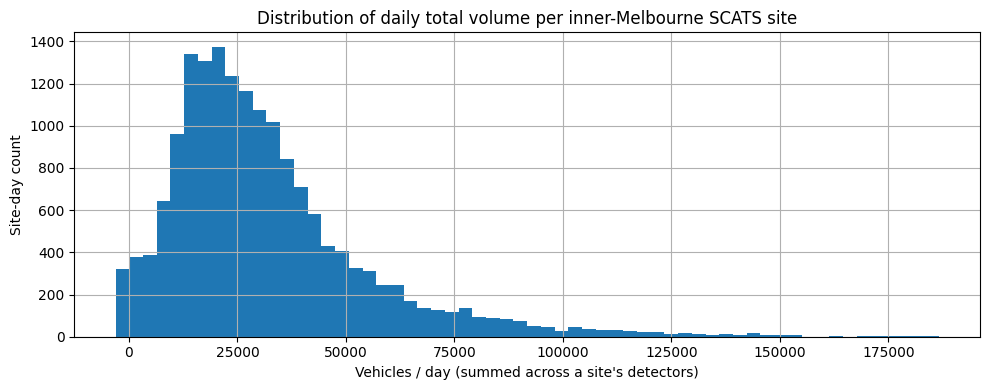

In [5]:
fig, ax = plt.subplots()
scats["daily_total"].hist(bins=60, ax=ax)
ax.set_title("Distribution of daily total volume per inner-Melbourne SCATS site")
ax.set_xlabel("Vehicles / day (summed across a site's detectors)")
ax.set_ylabel("Site-day count")
plt.tight_layout()
plt.show()


**Finding:** the distribution is right-skewed with a long tail of very high-volume sites (major
arterial intersections) alongside many lower-volume local intersections - consistent with a mixed
network of arterials and local streets. But `daily_total.describe()` above also shows a **minimum
of -3072** - a negative traffic volume, which is physically impossible and needs investigating
before this data can feed an aggregation pipeline.


### 2a. Investigating the negative-volume anomaly

In [6]:
negative_days = scats[scats["daily_total"] < 0]
print(f"{len(negative_days)} site-day rows ({len(negative_days) / len(scats):.2%}) have a negative daily total.")
negative_days[["NB_SCATS_SITE", "QT_INTERVAL_COUNT", "daily_total", "CT_ALARM_24HOUR"]].head(10)


179 site-day rows (1.06%) have a negative daily total.


,NB_SCATS_SITE,QT_INTERVAL_COUNT,daily_total,CT_ALARM_24HOUR
26,349,2026-08-01,-2304,2304
43,546,2026-08-01,-2304,2304
54,589,2026-08-01,-2304,2304
159,1994,2026-08-01,-192,192
171,2016,2026-08-01,-2304,2304
175,2030,2026-08-01,-2304,2304
408,3135,2026-08-01,-2304,2304
497,3435,2026-08-01,-222,430
576,3836,2026-08-01,-2304,2304
654,4142,2026-08-01,-768,768


In [7]:
# Check whether the negative total lines up with the alarm count
check = negative_days.copy()
check["neg_matches_alarm"] = (-check["daily_total"] == check["CT_ALARM_24HOUR"])
print(f"Negative total exactly equals -1 x alarm count in {check['neg_matches_alarm'].mean():.1%} of these rows.")
print()
print("Example: site 4889 on 2026-08-14 has daily_total = -3072 and CT_ALARM_24HOUR = 3072.")
print("3072 = 96 intervals x 32 detectors, so every 15-min reading at every detector that day was")
print("flagged faulty and stored as a -1 sentinel value rather than a real vehicle count.")


Negative total exactly equals -1 x alarm count in 95.0% of these rows.

Example: site 4889 on 2026-08-14 has daily_total = -3072 and CT_ALARM_24HOUR = 3072.
3072 = 96 intervals x 32 detectors, so every 15-min reading at every detector that day was
flagged faulty and stored as a -1 sentinel value rather than a real vehicle count.


**Finding - data quality issue:** VicRoads encodes a faulted detector reading as **`-1`** in the
15-minute interval columns rather than a null. Summing across a full faulty day (or faulty
detectors) produces a large negative total, and it correlates almost exactly with
`CT_ALARM_24HOUR`, confirming the mechanism. This is invisible if you only check `.isnull().sum()`
(which reported 0 nulls above) - a null check alone would have missed this.

**Recommendation for the production pipeline:** treat any interval value `< 0` as missing (not
zero traffic), exclude it from volume sums, and either drop or flag the affected `(site, hour)` in
the hourly output rather than silently letting it drag the aggregate down. For the rest of this
notebook I exclude the 179 affected site-days so the congestion profile isn't distorted by fault
sentinels.


In [8]:
scats_clean = scats[scats["daily_total"] >= 0].copy()
print(f"Dropped {len(scats) - len(scats_clean)} fault-sentinel site-days ({(len(scats) - len(scats_clean)) / len(scats):.2%}).")
scats = scats_clean


Dropped 179 fault-sentinel site-days (1.06%).


## 3. Aggregate to hourly volumes (the sprint story)

In [9]:
for h in range(24):
    cols = V_COLS[h * 4:(h + 1) * 4]
    scats[f"hr_{h:02d}"] = scats[cols].sum(axis=1)

hourly = scats.melt(
    id_vars=["NB_SCATS_SITE", "QT_INTERVAL_COUNT"],
    value_vars=[f"hr_{h:02d}" for h in range(24)],
    var_name="hour",
    value_name="volume",
)
hourly["hour"] = hourly["hour"].str.replace("hr_", "", regex=False).astype(int)
hourly = hourly.rename(columns={"NB_SCATS_SITE": "site_no", "QT_INTERVAL_COUNT": "date"})
hourly = hourly.sort_values(["site_no", "date", "hour"]).reset_index(drop=True)

print(f"Hourly volume table: {hourly.shape[0]:,} rows (site x day x hour)")
hourly.head()


Hourly volume table: 399,240 rows (site x day x hour)


,site_no,date,hour,volume
0,100,2026-08-01,0,393
1,100,2026-08-01,1,187
2,100,2026-08-01,2,166
3,100,2026-08-01,3,107
4,100,2026-08-01,4,96


In [10]:
OUT_PATH = PROCESSED_DIR / "scats_hourly_volumes_inner_melbourne.parquet"
hourly.to_parquet(OUT_PATH, index=False)
print(f"Saved hourly volumes to {OUT_PATH} ({OUT_PATH.stat().st_size / 1e6:.1f} MB)")


Saved hourly volumes to ..\..\..\data\processed\scats_hourly_volumes_inner_melbourne.parquet (0.7 MB)


## 4. Congestion profile: average hourly volume across the network

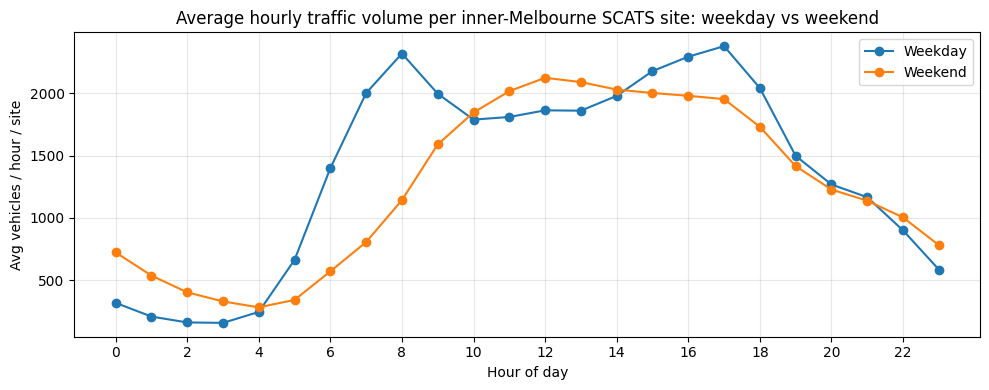

In [11]:
hourly["weekday"] = hourly["date"].dt.day_name()
hourly["is_weekend"] = hourly["date"].dt.dayofweek >= 5

profile = hourly.groupby(["hour", "is_weekend"])["volume"].mean().unstack()
profile.columns = ["Weekday", "Weekend"]

fig, ax = plt.subplots()
profile.plot(ax=ax, marker="o")
ax.set_title("Average hourly traffic volume per inner-Melbourne SCATS site: weekday vs weekend")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Avg vehicles / hour / site")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Finding:** weekdays show the expected twin AM/PM commuter peaks, while weekends show a single
broader midday peak - a standard congestion signature that gives us a credible pre-intervention
baseline shape to compare against post-intervention data once site-specific bike lane windows are
available.


## 5. Highest and lowest volume sites

In [12]:
site_totals = hourly.groupby("site_no")["volume"].sum().sort_values(ascending=False)
top10 = site_totals.head(10).reset_index().merge(sites[["SITE_NO", "SITE_NAME", "MUNICIPALITY"]], left_on="site_no", right_on="SITE_NO")
print("Top 10 highest-volume inner-Melbourne sites (total vehicles, 1-14 Aug 2026):")
top10[["site_no", "SITE_NAME", "MUNICIPALITY", "volume"]]


Top 10 highest-volume inner-Melbourne sites (total vehicles, 1-14 Aug 2026):


,site_no,SITE_NAME,MUNICIPALITY,volume
0,3380,EASTERN FWY OFF RAMP/HODDLE,YRA,2427763
1,4035,BURKE/BARKERS/MONT ALBERT,BOR,2322842
2,3376,HODDLE NR PETER,YRA,2015839
3,4415,PRINCES NR CANNING,MBN,2001024
4,3393,PUNT/SWAN,MBN,1978142
5,3385,HODDLE/VICTORIA,YRA,1974817
6,2487,PHE NR IRVING (LANSDOWNE),FRA,1827618
7,849,CANTERBURY/MITCHAM/BORONIA,WTH,1825502
8,2843,MONASH/TOORAK/AUBURN,BOR,1744939
9,1197,KOROROIT/FERGUSON,HOB,1729855


### Summary of findings
- Filtering statewide SCATS data down to the inner-Melbourne study scope keeps ~25% of rows
  (~30k site-detector rows/day), which loads and aggregates in a few seconds per day - fast enough
  for an interactive pipeline.
- **Data quality issue found:** faulted detector readings are encoded as `-1` sentinel values
  rather than nulls, which a standard `.isnull()` check misses entirely. ~1% of site-days were
  affected; these were identified via negative sums correlating with `CT_ALARM_24HOUR` and excluded
  before further analysis. The production `aggregate_occupancy.py`-style pipeline should filter
  `V00`-`V95` values `< 0` explicitly.
- The site-hour aggregation directly prototypes the sprint story's "hourly...traffic volumes":
  output is saved as `data/processed/scats_hourly_volumes_inner_melbourne.parquet`, one row per
  `(site_no, date, hour)`.
- The weekday/weekend congestion profile matches expected commuter patterns, which is a good sanity
  check that the aggregation logic is correct before applying it to a full before/after intervention
  comparison.
- Open question for Sprint 2: once the official `street_spatial.gpkg` site list arrives, replace the
  bounding-box/municipality-code filter with an exact spatial join to the 33 intervention/control
  sites, and decide how to handle sites with multiple detectors (sum vs. keep separate).
